Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
(704000, 2)


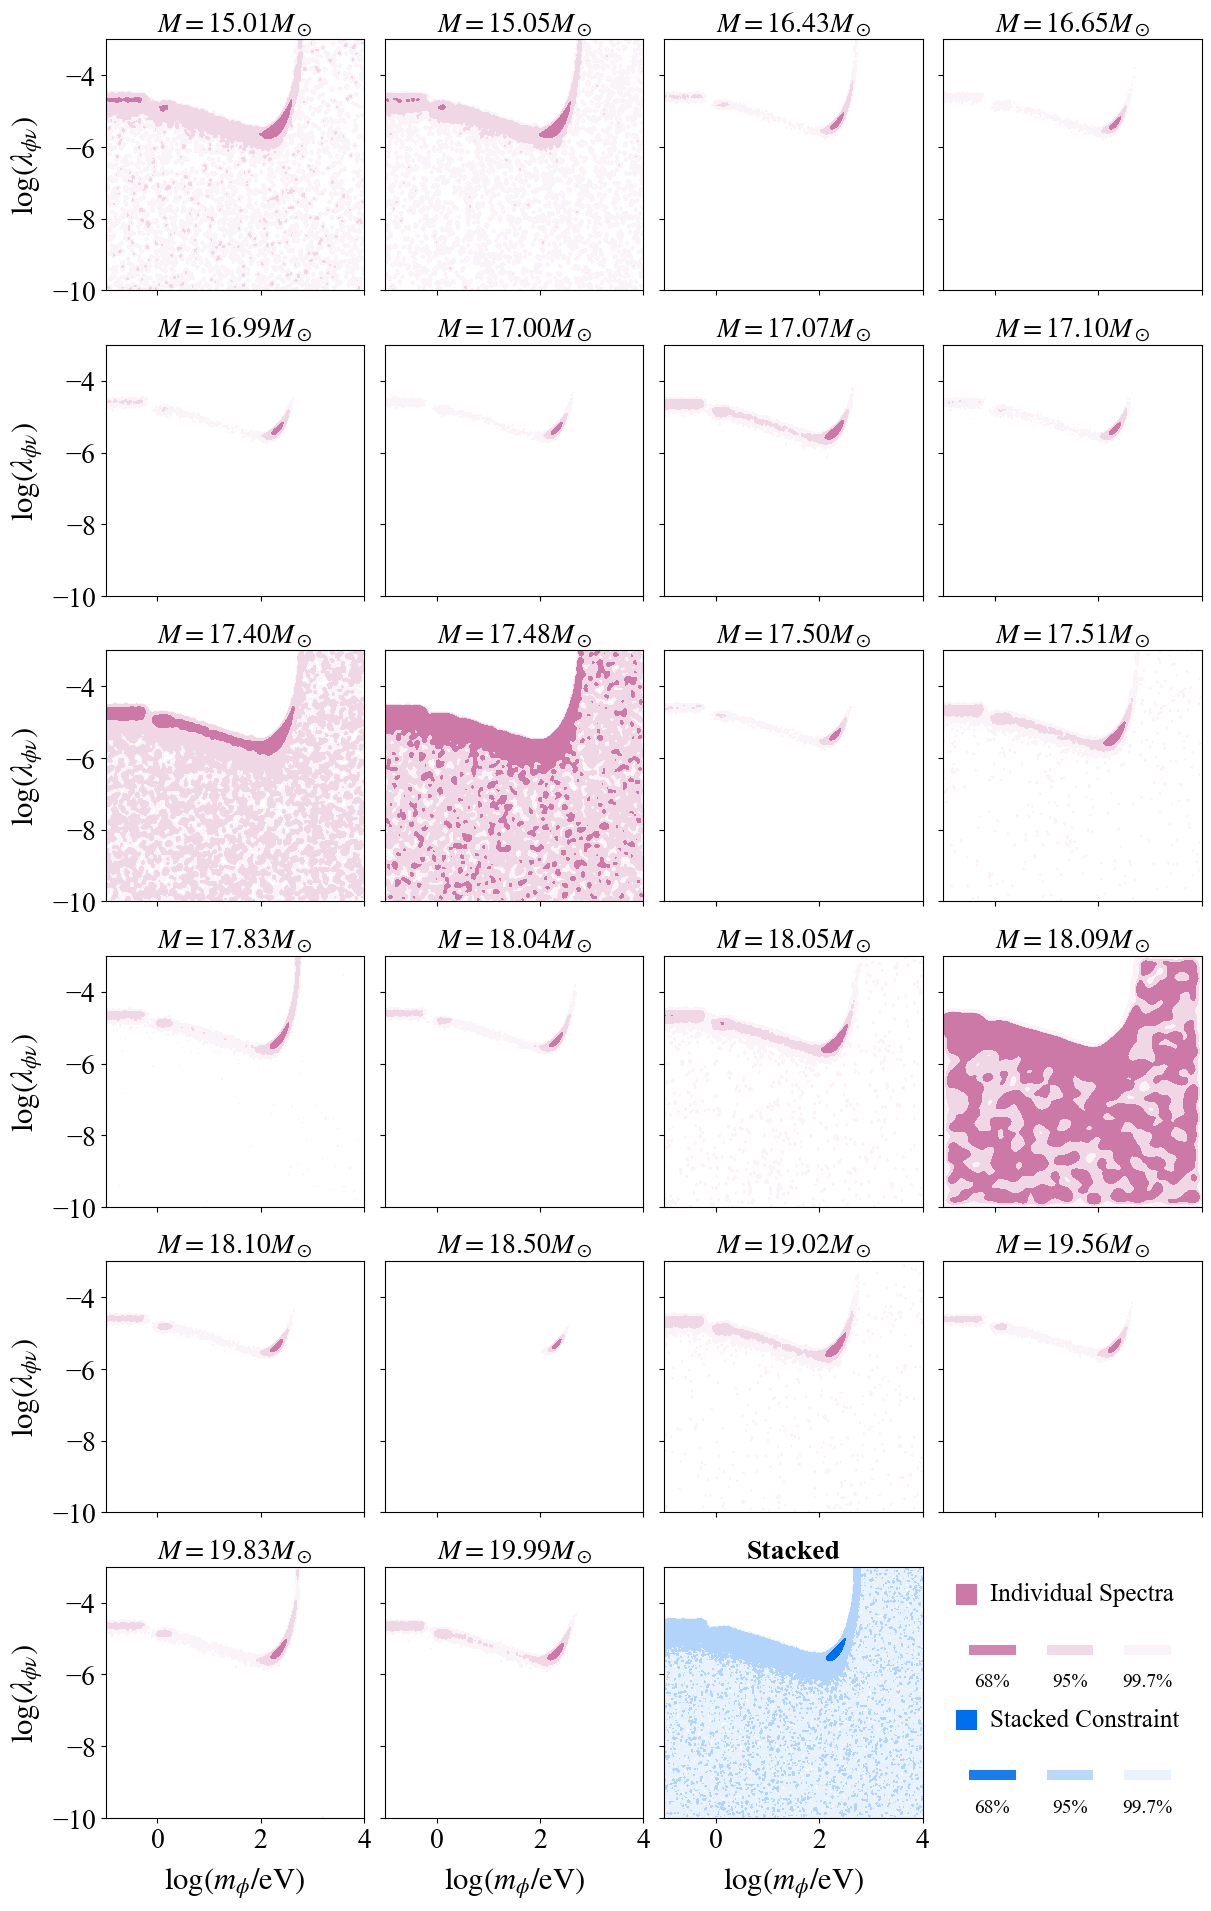

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import MCSamples, plots

# 1. Define your files and labels
effective_data_file = [
    '15.01', '15.05', '16.43', '16.65', '16.99', '17.00', '17.07', '17.10', '17.40', 
    '17.48', '17.50', '17.51', '17.83', '18.04', '18.05', '18.09', '18.10', '18.50',
    '19.02', '19.56', '19.83', '19.99'
]

param_names = ['logm', 'loglam']
param_labels = [r'\log(m_\phi/\mathrm{eV})', r'\log(\lambda_{\phi\nu})']


X_LIMITS = [-1.0, 4.0]  
Y_LIMITS = [-10.0, -3.0] 


mc_samples_list = []
titles = []
stacked_list = []

for file_id in effective_data_file:
    path = f'F:/Neutrino_SI/Bin/smellycat260622/data/2d_m{file_id}_5e5_p32_log.npy'
    arr = np.load(path)
    stacked_list.append(arr)
    sample = MCSamples(samples=arr, names=param_names, labels=param_labels, 
                       settings={'smooth_scale_2D': -1})
    sample.updateSettings({'contours': [0.68, 0.95, 0.997]})
    mc_samples_list.append(sample)
    titles.append(rf'$M = {file_id} M_\odot$')

stacked_arr = np.concatenate(stacked_list, axis=0)
stacked_sample = MCSamples(samples=stacked_arr, names=param_names, labels=param_labels,)
print(stacked_arr.shape)

stacked_sample.updateSettings({'contours': [0.68, 0.95, 0.997]})


mc_samples_list.append(stacked_sample)
titles.append('Stacked') # Title for the 23rd plot

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(12, 19), constrained_layout=True)
# (12, 19) for 6x4 vertical layout while (17.5, 13) for 4x6 horizontal layout

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'

axes_flat = axes.flatten()
g = plots.get_single_plotter()
g.settings.axes_labelsize = 22
g.settings.axes_fontsize = 20
# g.settings.legend_fontsize = 25

opacity, opacity_ratio = 0.9, 0.7

g.settings.num_plot_contours = 3
g.settings.alpha_factor_contour_lines = 0

g.settings.alpha_filled_add = opacity
g.settings.solid_contour_palefactor = opacity_ratio

for i, (title, sample) in enumerate(zip(titles, mc_samples_list)):
    ax = axes_flat[i]
    
    plot_color = "#006FED" if i == 22 else "#CC79A7" 
    g.plot_2d(sample, 'logm', 'loglam', ax=ax, filled=True, colors=[plot_color])
    
    # if i == 22:
    #     from scipy.ndimage import gaussian_filter1d
    # # --- EXTRACT HIGHEST 95% UPPER ENVELOPE ---
    
    #     density = sample.get2DDensity('logm', 'loglam')
    #     level_95 = density.getContourLevels([0.95])[0]
        
    #     # Initialize arrays for our clean line
    #     x_upper = density.x
    #     y_upper = np.full_like(x_upper, np.nan) 
        
    #     # Ensure grid is sliced correctly (usually shape is (ny, nx))
    #     P_grid = density.P if density.P.shape == (len(density.y), len(density.x)) else density.P.T
        
    #     # Scan vertically through every single x-column
    #     for ix in range(len(x_upper)):
    #         y_profile = P_grid[:, ix]
            
    #         # Find all y-indices in this column that are inside the 95% contour
    #         inside_indices = np.where(y_profile >= level_95)[0]
            
    #         if len(inside_indices) > 0:
    #             # The highest y-value index is the last one (since density.y is sorted ascending)
    #             max_y_idx = inside_indices[-1]
    #             y_upper[ix] = density.y[max_y_idx]

    #     # Optional: Apply a light smoothing filter to remove grid-resolution jaggedness
    #     valid = ~np.isnan(y_upper)
    #     y_upper[valid] = gaussian_filter1d(y_upper[valid], sigma=1.5)

    #     # Draw our single, clean upper line
    #     ax.plot(x_upper, y_upper, color='#333333', linewidth=1, linestyle='-', zorder=5)
        # ------------------------------------------

    ax.set_title(title, fontsize=20, fontweight='bold' if i == 22 else 'normal')
    
    # ENFORCE GLOBAL LIMITS HERE
    # if i <= 21:
    #     if effective_data_file[i] in ['15.01', '15.05', '17.40', '17.48', '18.09']:
    ax.set_xlim(X_LIMITS)
    ax.set_ylim(Y_LIMITS)
    

    if i % 4 != 0:
        ax.set_ylabel('')
        ax.tick_params(labelleft=False)  # Hide y-axis labels and ticks for non-leftmost plots
    if i < 20:
        ax.set_xlabel('')
        ax.tick_params(labelbottom=False)  # Hide x-axis labels and ticks for non-bottom plots


ax_legend = axes_flat[23]
ax_legend.axis('off') # Turn off the box and ticks


from matplotlib import patches

color_ind = "#CC79A7"
color_stack = "#006FED"
alphas = [opacity, opacity*(1-opacity_ratio), opacity*(1-opacity_ratio)**2]
cl_labels = ['68%', '95%', '99.7%']

# Dimensions for the shapes
card_w, card_h = 0.08, 0.08  # Main label 'Color card'
bar_w, bar_h = 0.18, 0.04    # Confidence level 'Color bars'

# ==========================================
# Block 1: Individual Mass Spectra
# ==========================================
# Line 1: Main color card and title
y_line1 = 0.85
ax_legend.add_patch(patches.Rectangle((0.05, y_line1), card_w, card_h, 
                                      facecolor=color_ind, transform=ax_legend.transAxes))
ax_legend.text(0.18, y_line1 + card_h/2, 'Individual Spectra', 
               va='center', ha='left', fontsize=18, transform=ax_legend.transAxes)

# Line 2 & 3: C.L. Bars and Text
y_line2 = 0.65  # Y-position for the transparent bars
y_line3 = 0.58  # Y-position for the text underneath
for j, (alpha, label) in enumerate(zip(alphas, cl_labels)):
    x_pos = 0.1 + j * 0.3  # Horizontally space bars at x = 0.1, 0.4, 0.7
    
    # Draw the bar (Line 2)
    ax_legend.add_patch(patches.Rectangle((x_pos, y_line2), bar_w, bar_h, 
                                          facecolor=color_ind, alpha=alpha, 
                                          transform=ax_legend.transAxes))
    # Draw the text aligned to the center of the bar (Line 3)
    ax_legend.text(x_pos + bar_w/2, y_line3, label, 
                   va='top', ha='center', fontsize=14, transform=ax_legend.transAxes)


# ==========================================
# Block 2: Stacked Constraint
# ==========================================
# Line 4: Main color card and title
y_line4 = 0.35
ax_legend.add_patch(patches.Rectangle((0.05, y_line4), card_w, card_h, 
                                      facecolor=color_stack, transform=ax_legend.transAxes))
ax_legend.text(0.18, y_line4 + card_h/2, 'Stacked Constraint', 
               va='center', ha='left', fontsize=18, transform=ax_legend.transAxes)

# Line 5 & 6: C.L. Bars and Text
y_line5 = 0.15  # Y-position for the transparent bars
y_line6 = 0.08  # Y-position for the text underneath
for j, (alpha, label) in enumerate(zip(alphas, cl_labels)):
    x_pos = 0.1 + j * 0.3  # Horizontally space bars at x = 0.1, 0.4, 0.7
    
    # Draw the bar (Line 5)
    ax_legend.add_patch(patches.Rectangle((x_pos, y_line5), bar_w, bar_h, 
                                          facecolor=color_stack, alpha=alpha, 
                                          transform=ax_legend.transAxes))
    # Draw the text aligned to the center of the bar (Line 6)
    ax_legend.text(x_pos + bar_w/2, y_line6, label, 
                   va='top', ha='center', fontsize=14, transform=ax_legend.transAxes)



fig.savefig(r'F:/Neutrino_SI/Plots/2d_sim_all.pdf', bbox_inches='tight')

fig

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
(704000, 2)
Removed no burn in


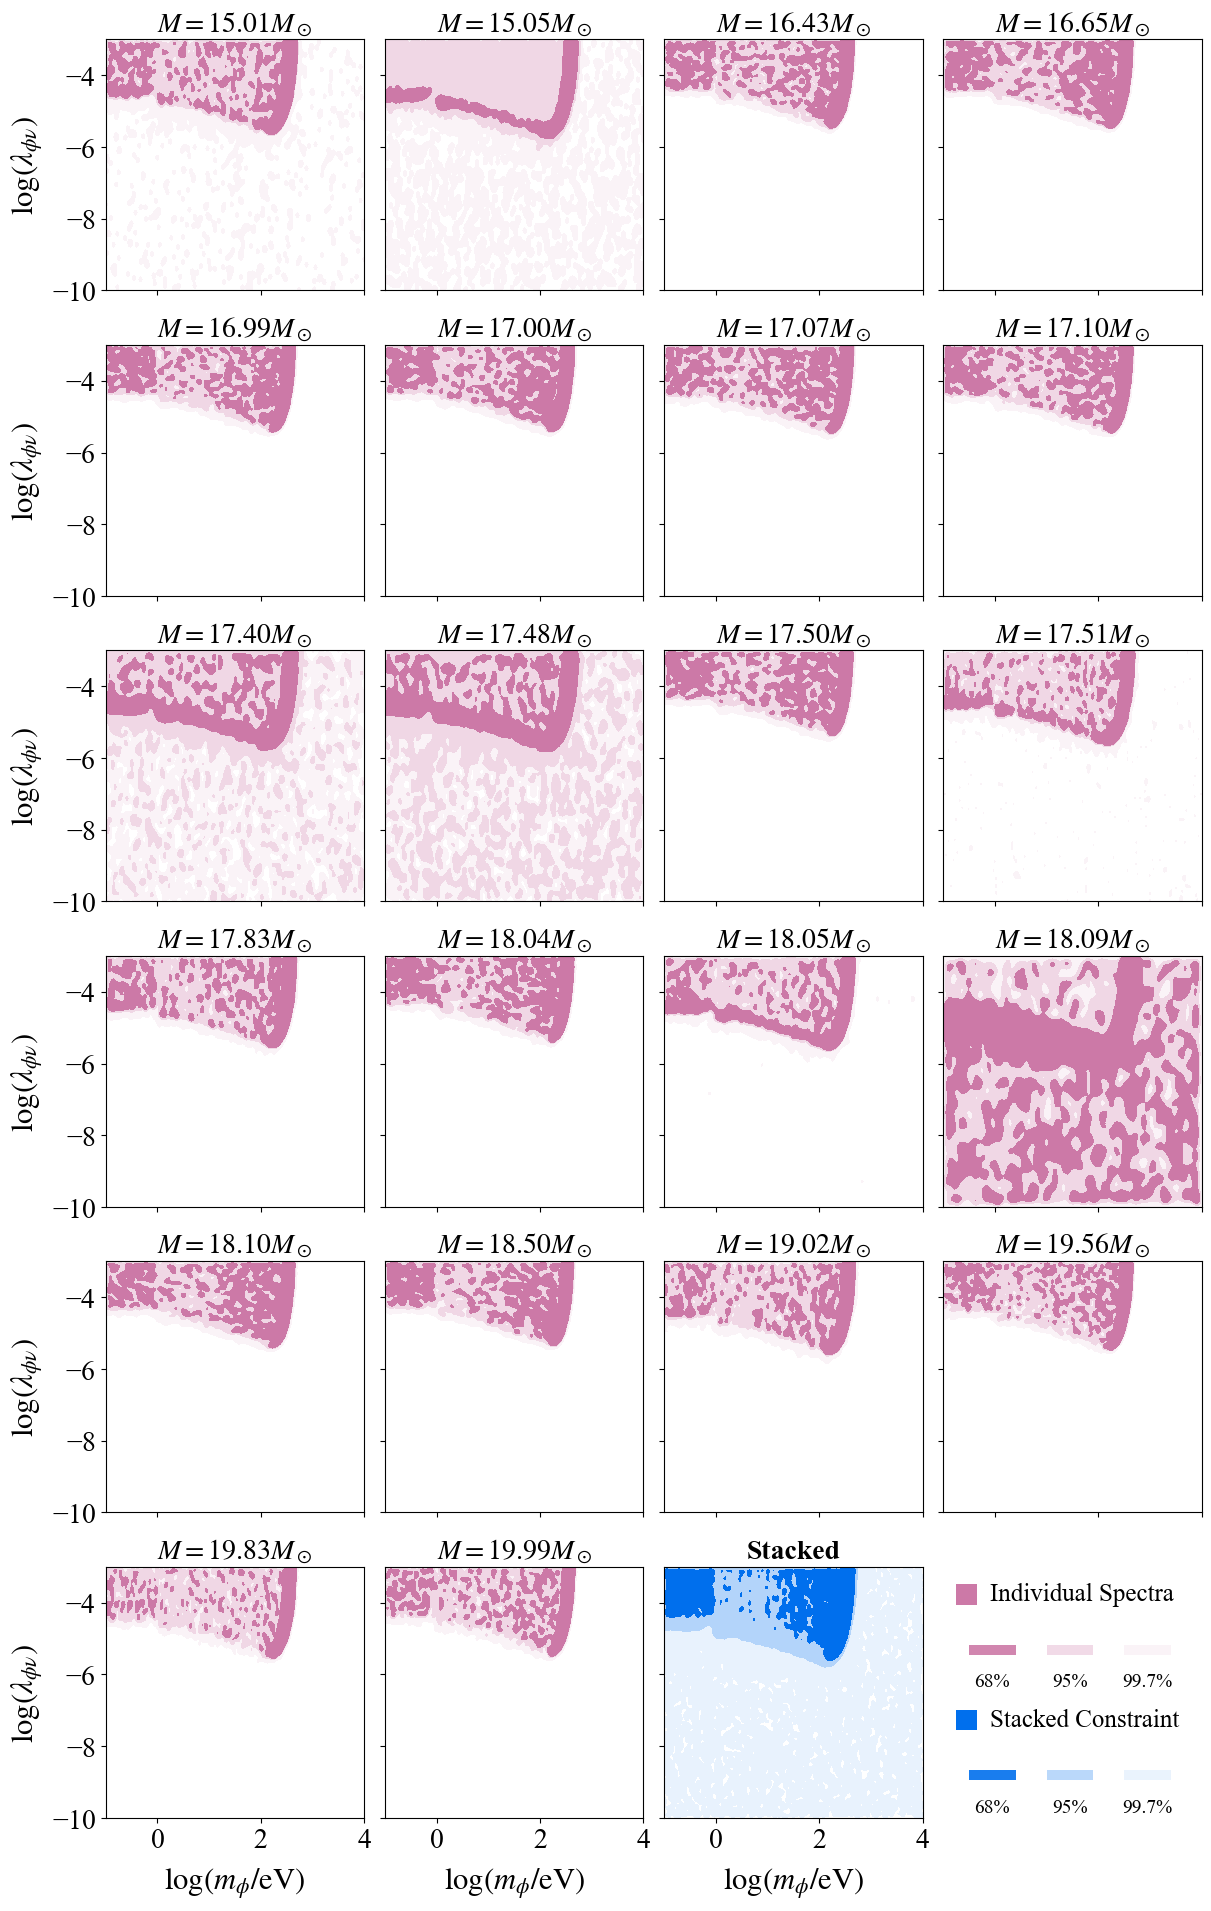

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import MCSamples, plots


effective_data_file = [
    '15.01', '15.05', '16.43', '16.65', '16.99', '17.00', '17.07', '17.10', '17.40', 
    '17.48', '17.50', '17.51', '17.83', '18.04', '18.05', '18.09', '18.10', '18.50',
    '19.02', '19.56', '19.83', '19.99'
]

param_names = ['logm', 'loglam']
param_labels = [r'\log(m_\phi/\mathrm{eV})', r'\log(\lambda_{\phi\nu})']

X_LIMITS = [-1.0, 4.0]  
Y_LIMITS = [-10.0, -3.0] 

mc_samples_list = []
titles = []
stacked_list = []

for file_id in effective_data_file:
    path = f'F:/Neutrino_SI/Bin/smellycat260622/data/2d_m{file_id}_5e5_p32_log_osc.npy'
    arr = np.load(path)
    stacked_list.append(arr)
    sample = MCSamples(samples=arr, names=param_names, labels=param_labels)
    sample.updateSettings({'contours': [0.68, 0.95, 0.997]})
    mc_samples_list.append(sample)
    titles.append(rf'$M = {file_id} M_\odot$')


stacked_arr = np.concatenate(stacked_list, axis=0)
print(stacked_arr.shape)
stacked_sample = MCSamples(samples=stacked_arr, names=param_names, labels=param_labels)
stacked_sample.updateSettings({'contours': [0.68, 0.95, 0.997]})

mc_samples_list.append(stacked_sample)
titles.append('Stacked') # Title for the 23rd plot

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(12, 19), constrained_layout=True)
# (12, 19) for 6x4 vertical layout while (17.5, 13) for 4x6 horizontal layout

axes_flat = axes.flatten()
g = plots.get_single_plotter()

g.settings.axes_labelsize = 22
g.settings.axes_fontsize = 20

opacity, opacity_ratio = 0.9, 0.7

g.settings.num_plot_contours = 3
g.settings.alpha_factor_contour_lines = 0

g.settings.alpha_filled_add = opacity
g.settings.solid_contour_palefactor = opacity_ratio

for i, (title, sample) in enumerate(zip(titles, mc_samples_list)):
    ax = axes_flat[i]
    
    plot_color = "#006FED" if i == 22 else "#CC79A7" 
    g.plot_2d(sample, 'logm', 'loglam', ax=ax, filled=True, colors=[plot_color])
    
    # if i == 22:
    #     from scipy.ndimage import gaussian_filter1d
    # # --- EXTRACT HIGHEST 95% UPPER ENVELOPE ---
    
    #     density = sample.get2DDensity('logm', 'loglam')
    #     level_95 = density.getContourLevels([0.95])[0]
        
    #     # Initialize arrays for our clean line
    #     x_upper = density.x
    #     y_upper = np.full_like(x_upper, np.nan) 
        
    #     # Ensure grid is sliced correctly (usually shape is (ny, nx))
    #     P_grid = density.P if density.P.shape == (len(density.y), len(density.x)) else density.P.T
        
    #     # Scan vertically through every single x-column
    #     for ix in range(len(x_upper)):
    #         y_profile = P_grid[:, ix]
            
    #         # Find all y-indices in this column that are inside the 95% contour
    #         inside_indices = np.where(y_profile >= level_95)[0]
            
    #         if len(inside_indices) > 0:
    #             # The highest y-value index is the last one (since density.y is sorted ascending)
    #             min_y_idx = inside_indices[0]
    #             y_upper[ix] = density.y[min_y_idx]

    #     # Draw our single, clean upper line
    #     ax.plot(x_upper, y_upper, color='#333333', linewidth=1, linestyle='-', zorder=5)
        # ------------------------------------------

    ax.set_title(title, fontsize=20, fontweight='bold' if i == 22 else 'normal')
    
    # ENFORCE GLOBAL LIMITS HERE
    # if i <= 21:
    #     if effective_data_file[i] in ['15.01', '15.05', '17.40', '17.48', '18.09']:
    ax.set_xlim(X_LIMITS)
    ax.set_ylim(Y_LIMITS)
    

    if i % 4 != 0:
        ax.set_ylabel('')
        ax.tick_params(labelleft=False)  # Hide y-axis labels and ticks for non-leftmost plots
    if i < 20:
        ax.set_xlabel('')
        ax.tick_params(labelbottom=False)  # Hide x-axis labels and ticks for non-bottom plots


ax_legend = axes_flat[23]
ax_legend.axis('off') # Turn off the box and ticks


from matplotlib import patches

color_ind = "#CC79A7"
color_stack = "#006FED"
alphas = [opacity, opacity*(1-opacity_ratio), opacity*(1-opacity_ratio)**2]
cl_labels = ['68%', '95%', '99.7%']

card_w, card_h = 0.08, 0.08  
bar_w, bar_h = 0.18, 0.04    

y_line1 = 0.85
ax_legend.add_patch(patches.Rectangle((0.05, y_line1), card_w, card_h, 
                                      facecolor=color_ind, transform=ax_legend.transAxes))
ax_legend.text(0.18, y_line1 + card_h/2, 'Individual Spectra', 
               va='center', ha='left', fontsize=18, transform=ax_legend.transAxes)

y_line2 = 0.65  
y_line3 = 0.58  
for j, (alpha, label) in enumerate(zip(alphas, cl_labels)):
    x_pos = 0.1 + j * 0.3  
    
    ax_legend.add_patch(patches.Rectangle((x_pos, y_line2), bar_w, bar_h, 
                                          facecolor=color_ind, alpha=alpha, 
                                          transform=ax_legend.transAxes))
    ax_legend.text(x_pos + bar_w/2, y_line3, label, 
                   va='top', ha='center', fontsize=14, transform=ax_legend.transAxes)


y_line4 = 0.35
ax_legend.add_patch(patches.Rectangle((0.05, y_line4), card_w, card_h, 
                                      facecolor=color_stack, transform=ax_legend.transAxes))
ax_legend.text(0.18, y_line4 + card_h/2, 'Stacked Constraint', 
               va='center', ha='left', fontsize=18, transform=ax_legend.transAxes)

y_line5 = 0.15 
y_line6 = 0.08 
for j, (alpha, label) in enumerate(zip(alphas, cl_labels)):
    x_pos = 0.1 + j * 0.3
    
    ax_legend.add_patch(patches.Rectangle((x_pos, y_line5), bar_w, bar_h, 
                                          facecolor=color_stack, alpha=alpha, 
                                          transform=ax_legend.transAxes))
    ax_legend.text(x_pos + bar_w/2, y_line6, label, 
                   va='top', ha='center', fontsize=14, transform=ax_legend.transAxes)
    

fig.savefig(r'F:/Neutrino_SI/Plots/2d_sim_all_osc.pdf', bbox_inches='tight')

fig

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
(704000, 2)
Removed no burn in


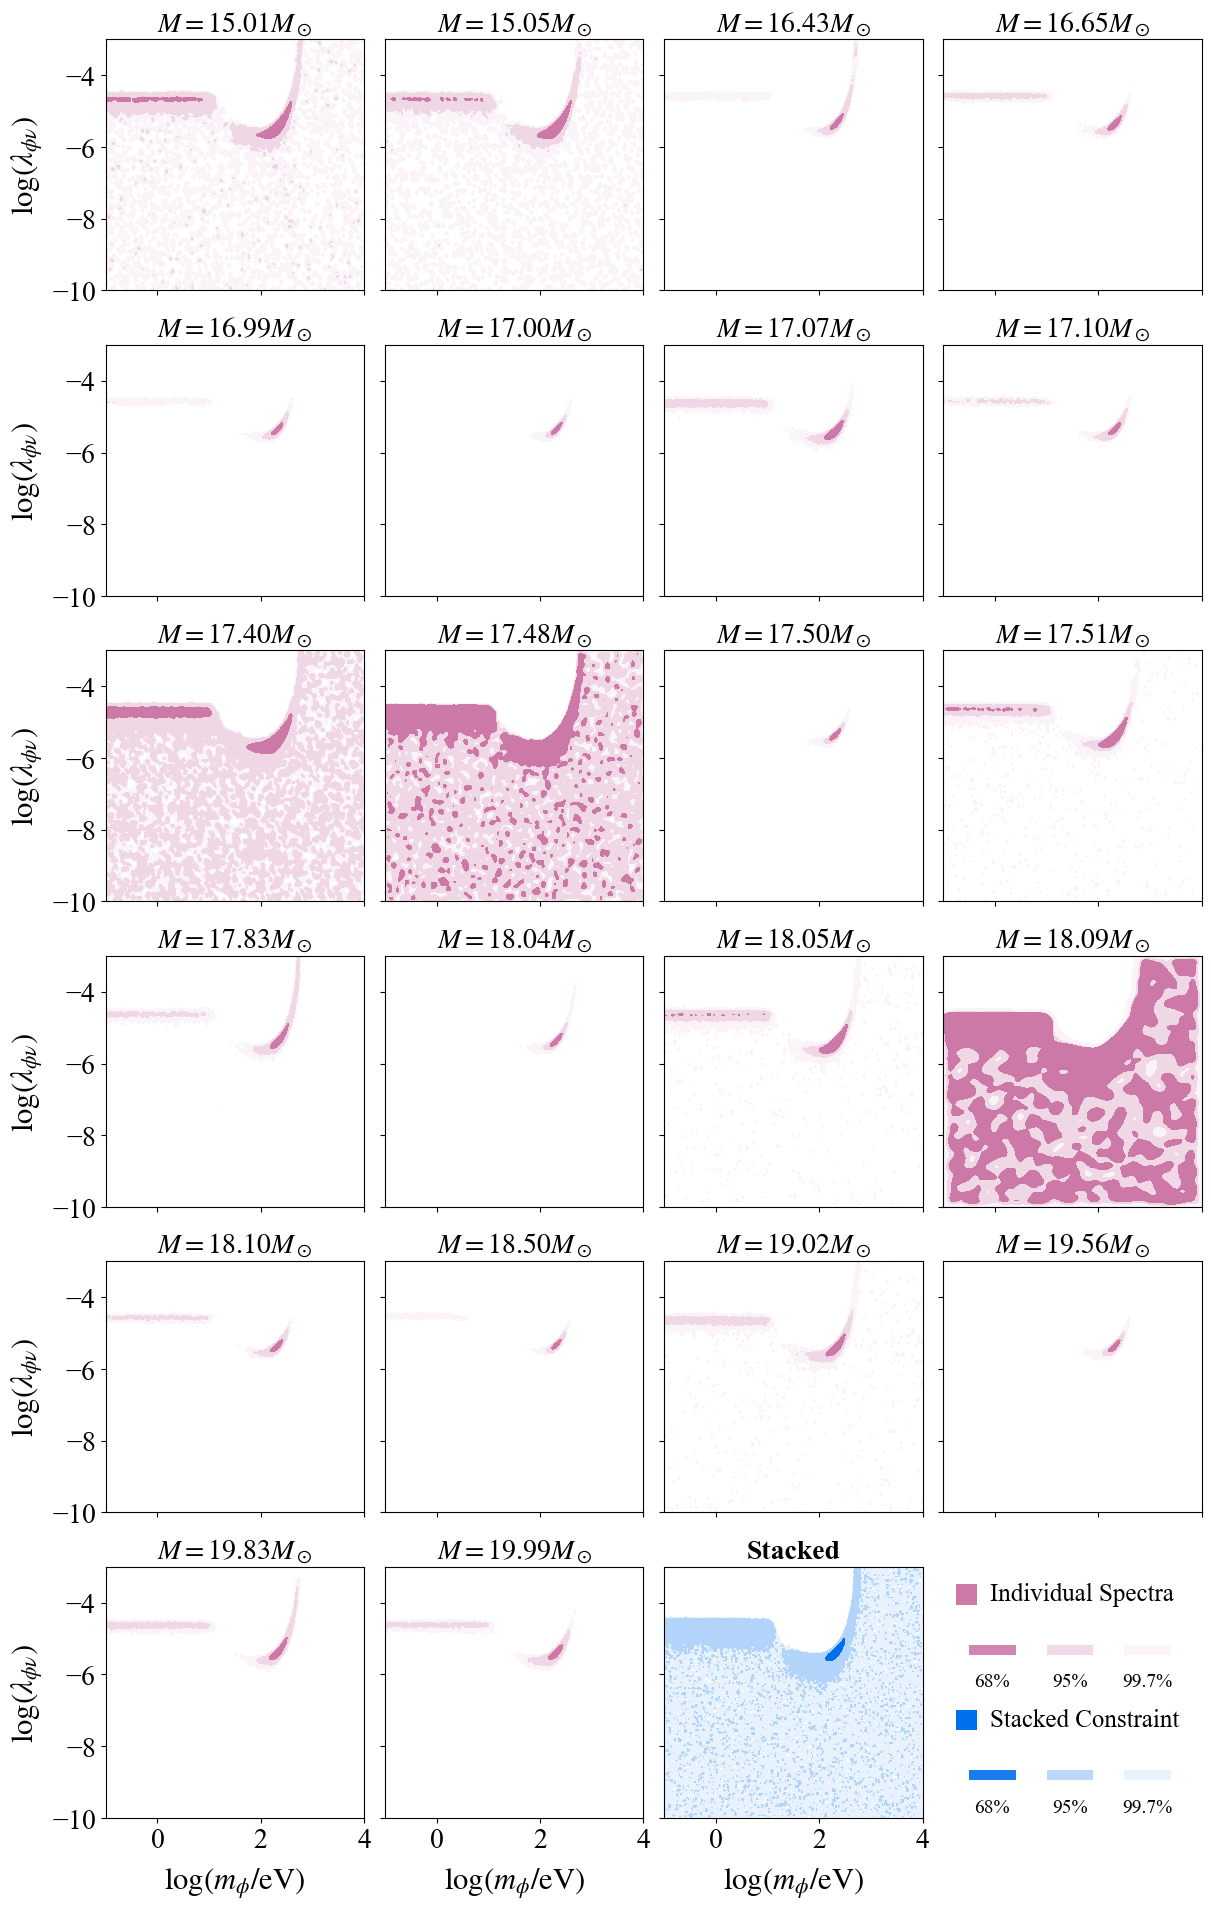

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import MCSamples, plots

effective_data_file = [
    '15.01', '15.05', '16.43', '16.65', '16.99', '17.00', '17.07', '17.10', '17.40', 
    '17.48', '17.50', '17.51', '17.83', '18.04', '18.05', '18.09', '18.10', '18.50',
    '19.02', '19.56', '19.83', '19.99'
]

param_names = ['logm', 'loglam']
param_labels = [r'\log(m_\phi/\mathrm{eV})', r'\log(\lambda_{\phi\nu})']

X_LIMITS = [-1.0, 4.0]  
Y_LIMITS = [-10.0, -3.0] 

mc_samples_list = []
titles = []
stacked_list = []

for file_id in effective_data_file:
    path = f'F:/Neutrino_SI/Bin/smellycat260622/data/2d_m{file_id}_5e5_p32_log_rmnu.npy'
    arr = np.load(path)
    stacked_list.append(arr)
    sample = MCSamples(samples=arr, names=param_names, labels=param_labels)
    sample.updateSettings({'contours': [0.68, 0.95, 0.997]})
    mc_samples_list.append(sample)
    titles.append(rf'$M = {file_id} M_\odot$')


stacked_arr = np.concatenate(stacked_list, axis=0)
print(stacked_arr.shape)
stacked_sample = MCSamples(samples=stacked_arr, names=param_names, labels=param_labels)
stacked_sample.updateSettings({'contours': [0.68, 0.95, 0.997]})

mc_samples_list.append(stacked_sample)
titles.append('Stacked') # Title for the 23rd plot

fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(12, 19), constrained_layout=True)
# (12, 19) for 6x4 vertical layout while (17.5, 13) for 4x6 horizontal layout

axes_flat = axes.flatten()
g = plots.get_single_plotter()

g.settings.axes_labelsize = 22
g.settings.axes_fontsize = 20

opacity, opacity_ratio = 0.9, 0.7

g.settings.num_plot_contours = 3
g.settings.alpha_factor_contour_lines = 0

g.settings.alpha_filled_add = opacity
g.settings.solid_contour_palefactor = opacity_ratio

for i, (title, sample) in enumerate(zip(titles, mc_samples_list)):
    ax = axes_flat[i]
    
    plot_color = "#006FED" if i == 22 else "#CC79A7" 
    g.plot_2d(sample, 'logm', 'loglam', ax=ax, filled=True, colors=[plot_color])
    
    # if i == 22:
    #     from scipy.ndimage import gaussian_filter1d
    # # --- EXTRACT HIGHEST 95% UPPER ENVELOPE ---
    
    #     density = sample.get2DDensity('logm', 'loglam')
    #     level_95 = density.getContourLevels([0.95])[0]
        
    #     # Initialize arrays for our clean line
    #     x_upper = density.x
    #     y_upper = np.full_like(x_upper, np.nan) 
        
    #     # Ensure grid is sliced correctly (usually shape is (ny, nx))
    #     P_grid = density.P if density.P.shape == (len(density.y), len(density.x)) else density.P.T
        
    #     # Scan vertically through every single x-column
    #     for ix in range(len(x_upper)):
    #         y_profile = P_grid[:, ix]
            
    #         # Find all y-indices in this column that are inside the 95% contour
    #         inside_indices = np.where(y_profile >= level_95)[0]
            
    #         if len(inside_indices) > 0:
    #             # The highest y-value index is the last one (since density.y is sorted ascending)
    #             min_y_idx = inside_indices[0]
    #             y_upper[ix] = density.y[min_y_idx]

    #     # Draw our single, clean upper line
    #     ax.plot(x_upper, y_upper, color='#333333', linewidth=1, linestyle='-', zorder=5)
        # ------------------------------------------

    ax.set_title(title, fontsize=20, fontweight='bold' if i == 22 else 'normal')
    
    # ENFORCE GLOBAL LIMITS HERE
    # if i <= 21:
    #     if effective_data_file[i] in ['15.01', '15.05', '17.40', '17.48', '18.09']:
    ax.set_xlim(X_LIMITS)
    ax.set_ylim(Y_LIMITS)
    

    if i % 4 != 0:
        ax.set_ylabel('')
        ax.tick_params(labelleft=False)  # Hide y-axis labels and ticks for non-leftmost plots
    if i < 20:
        ax.set_xlabel('')
        ax.tick_params(labelbottom=False)  # Hide x-axis labels and ticks for non-bottom plots


ax_legend = axes_flat[23]
ax_legend.axis('off') # Turn off the box and ticks


from matplotlib import patches

color_ind = "#CC79A7"
color_stack = "#006FED"
alphas = [opacity, opacity*(1-opacity_ratio), opacity*(1-opacity_ratio)**2]
cl_labels = ['68%', '95%', '99.7%']

card_w, card_h = 0.08, 0.08  
bar_w, bar_h = 0.18, 0.04    

y_line1 = 0.85
ax_legend.add_patch(patches.Rectangle((0.05, y_line1), card_w, card_h, 
                                      facecolor=color_ind, transform=ax_legend.transAxes))
ax_legend.text(0.18, y_line1 + card_h/2, 'Individual Spectra', 
               va='center', ha='left', fontsize=18, transform=ax_legend.transAxes)

y_line2 = 0.65  
y_line3 = 0.58  
for j, (alpha, label) in enumerate(zip(alphas, cl_labels)):
    x_pos = 0.1 + j * 0.3  
    
    ax_legend.add_patch(patches.Rectangle((x_pos, y_line2), bar_w, bar_h, 
                                          facecolor=color_ind, alpha=alpha, 
                                          transform=ax_legend.transAxes))
    ax_legend.text(x_pos + bar_w/2, y_line3, label, 
                   va='top', ha='center', fontsize=14, transform=ax_legend.transAxes)


y_line4 = 0.35
ax_legend.add_patch(patches.Rectangle((0.05, y_line4), card_w, card_h, 
                                      facecolor=color_stack, transform=ax_legend.transAxes))
ax_legend.text(0.18, y_line4 + card_h/2, 'Stacked Constraint', 
               va='center', ha='left', fontsize=18, transform=ax_legend.transAxes)

y_line5 = 0.15 
y_line6 = 0.08 
for j, (alpha, label) in enumerate(zip(alphas, cl_labels)):
    x_pos = 0.1 + j * 0.3
    
    ax_legend.add_patch(patches.Rectangle((x_pos, y_line5), bar_w, bar_h, 
                                          facecolor=color_stack, alpha=alpha, 
                                          transform=ax_legend.transAxes))
    ax_legend.text(x_pos + bar_w/2, y_line6, label, 
                   va='top', ha='center', fontsize=14, transform=ax_legend.transAxes)
    

fig.savefig(r'F:/Neutrino_SI/Plots/2d_sim_all_rmnu.pdf', bbox_inches='tight')

fig